# Timer Testing Technical Report

## Methods

Timing accuracy was evaluated using both software logging and direct oscilloscope measurements.

For logging-based measurements, timestamps were captured inside the heartbeat_timer_handler and action_timer_handler functions in main.c. To avoid distortion from asynchronous logging latency, the execution time of each handler was first saved using k_uptime_ticks() and converted to nanoseconds via k_ticks_to_ns_near64(). The elapsed time between successive toggles was computed and logged as "toggle period (ns)". Terminal output for each operating condition (1 Hz, 2 Hz default, and 5 Hz) was copied into .txt files and parsed in a Jupyter notebook using pandas.

Because k_uptime_ticks() is quantized to the system clock tick, timing measurements are limited to one tick of resolution. This resolution was used to estimate the 95% confidence interval when repeated measurements produced identical values.

For oscilloscope measurements, both action LEDs were connected to separate channels of a digital oscilloscope using the accessible GPIO header pins on the nRF52833 DK. The two signals were overlaid to verify phase behavior. The oscilloscope’s built-in measurement tools were used to measure period and frequency across at least five cycles for both the lowest (1 Hz) and highest (5 Hz) action LED frequencies.

## Results

In [25]:
# import CSV files and read "action" + "heart" data
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def read_type(fname, keyword):
    df = pd.read_csv(fname, sep=r"\s+", header=None, usecols=[0,3,7],
                     names=['timestamp','type','toggle duration (ns)'],
                     engine="python")
    df = df[df['type'].astype(str).str.contains(keyword, case=False, na=False)].copy()
    df['frequency (Hz)'] = 1e9 / (2 * df['toggle duration (ns)'])
    return df

# 1 Hz file
log_1Hz_action = read_type('log_1Hz.txt', 'action')
log_1Hz_heart  = read_type('log_1Hz.txt', 'heart')

# 2 Hz file
log_2Hz_action = read_type('log_2Hz.txt', 'action')
log_2Hz_heart  = read_type('log_2Hz.txt', 'heart')

# 5 Hz file
log_5Hz_action = read_type('log_5Hz.txt', 'action')
log_5Hz_heart  = read_type('log_5Hz.txt', 'heart')

In [26]:
# Action summary
summary_action = pd.DataFrame({
    '1 Hz (action)': log_1Hz_action['frequency (Hz)'].describe(),
    '2 Hz (action)': log_2Hz_action['frequency (Hz)'].describe(),
    '5 Hz (action)': log_5Hz_action['frequency (Hz)'].describe()
})

# Heartbeat summary
summary_heart = pd.DataFrame({
    '1 Hz file (heart)': log_1Hz_heart['frequency (Hz)'].describe(),
    '2 Hz file (heart)': log_2Hz_heart['frequency (Hz)'].describe(),
    '5 Hz file (heart)': log_5Hz_heart['frequency (Hz)'].describe()
})
from IPython.display import display

display(summary_action)
display(summary_heart)

,1 Hz (action),2 Hz (action),5 Hz (action)
count,110.0,190.0,2.530000e+02
mean,1.0,2.0,4.999695e+00
std,0.0,0.0,2.503064e-08
min,1.0,2.0,4.999695e+00
25%,1.0,2.0,4.999695e+00
50%,1.0,2.0,4.999695e+00
75%,1.0,2.0,4.999695e+00
max,1.0,2.0,4.999695e+00


,1 Hz file (heart),2 Hz file (heart),5 Hz file (heart)
count,110.0,95.0,51.0
mean,1.0,1.0,1.0
std,0.0,0.0,0.0
min,1.0,1.0,1.0
25%,1.0,1.0,1.0
50%,1.0,1.0,1.0
75%,1.0,1.0,1.0
max,1.0,1.0,1.0


### 95% Confidence Interval for Heartbeat and Action LEDs

In [29]:
ticks_per_sec = 1e3  # your actual value
tick_s = 1 / ticks_per_sec
half_tick_s = tick_s / 2

def resolution_ci_period(mean_freq, decimals=3):
    mean_period_s = 1 / mean_freq
    lower = mean_period_s - half_tick_s
    upper = mean_period_s + half_tick_s
    return (round(lower*1000, decimals),
            round(upper*1000, decimals))  # return ms

# Action CIs
ci_1_action = resolution_ci_period(log_1Hz_action["frequency (Hz)"].mean())
ci_2_action = resolution_ci_period(log_2Hz_action["frequency (Hz)"].mean())
ci_5_action = resolution_ci_period(log_5Hz_action["frequency (Hz)"].mean())

# Heartbeat CIs
ci_1_heart = resolution_ci_period(log_1Hz_heart["frequency (Hz)"].mean())
ci_2_heart = resolution_ci_period(log_2Hz_heart["frequency (Hz)"].mean())
ci_5_heart = resolution_ci_period(log_5Hz_heart["frequency (Hz)"].mean())

ci_table = pd.DataFrame({
    "1 Hz": [ci_1_action, ci_1_heart],
    "2 Hz": [ci_2_action, ci_2_heart],
    "5 Hz": [ci_5_action, ci_5_heart]
}, index=["Action 95% CI (ms)", "Heartbeat 95% CI (ms)"])

display(ci_table)

,1 Hz,2 Hz,5 Hz
Action 95% CI (ms),"(999.5, 1000.5)","(499.5, 500.5)","(199.512, 200.512)"
Heartbeat 95% CI (ms),"(999.5, 1000.5)","(999.5, 1000.5)","(999.5, 1000.5)"


## Oscilloscope Measurements

### 1 Hz Oscilloscope Output

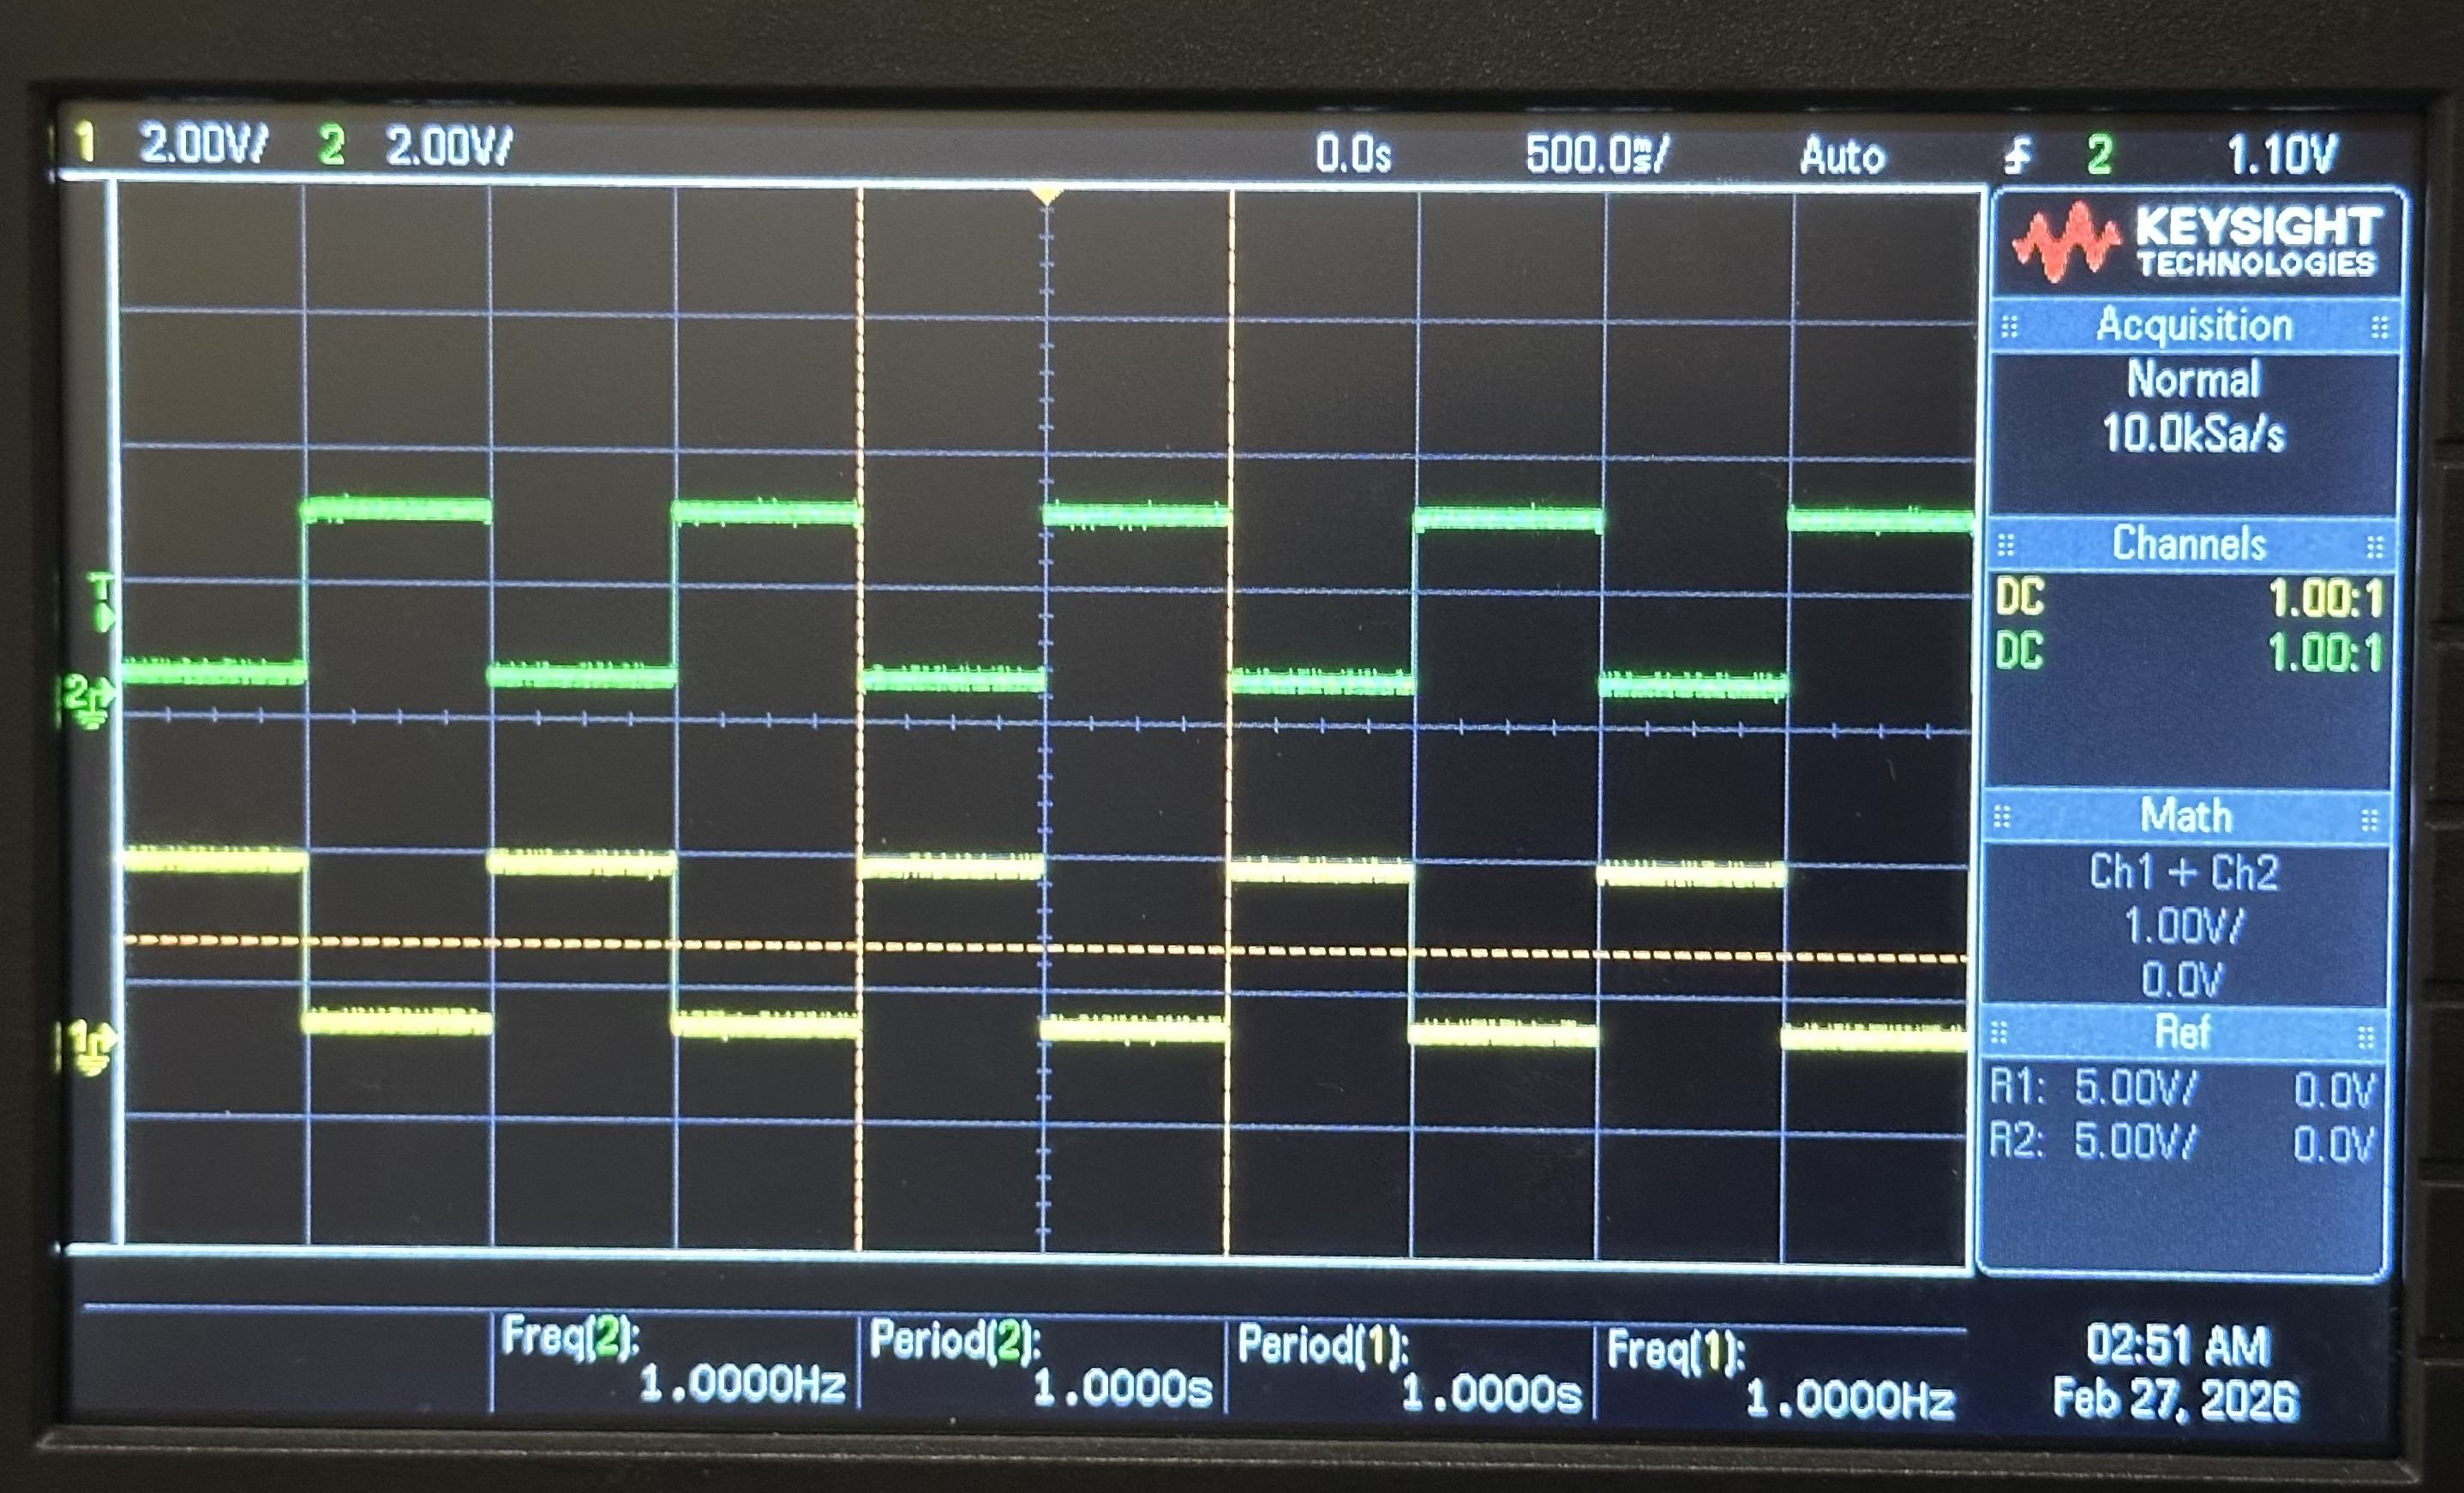

In [30]:
from IPython.display import Image, display

display(Image("scope_1Hz.jpeg"))

### 5 Hz Oscilloscope Output

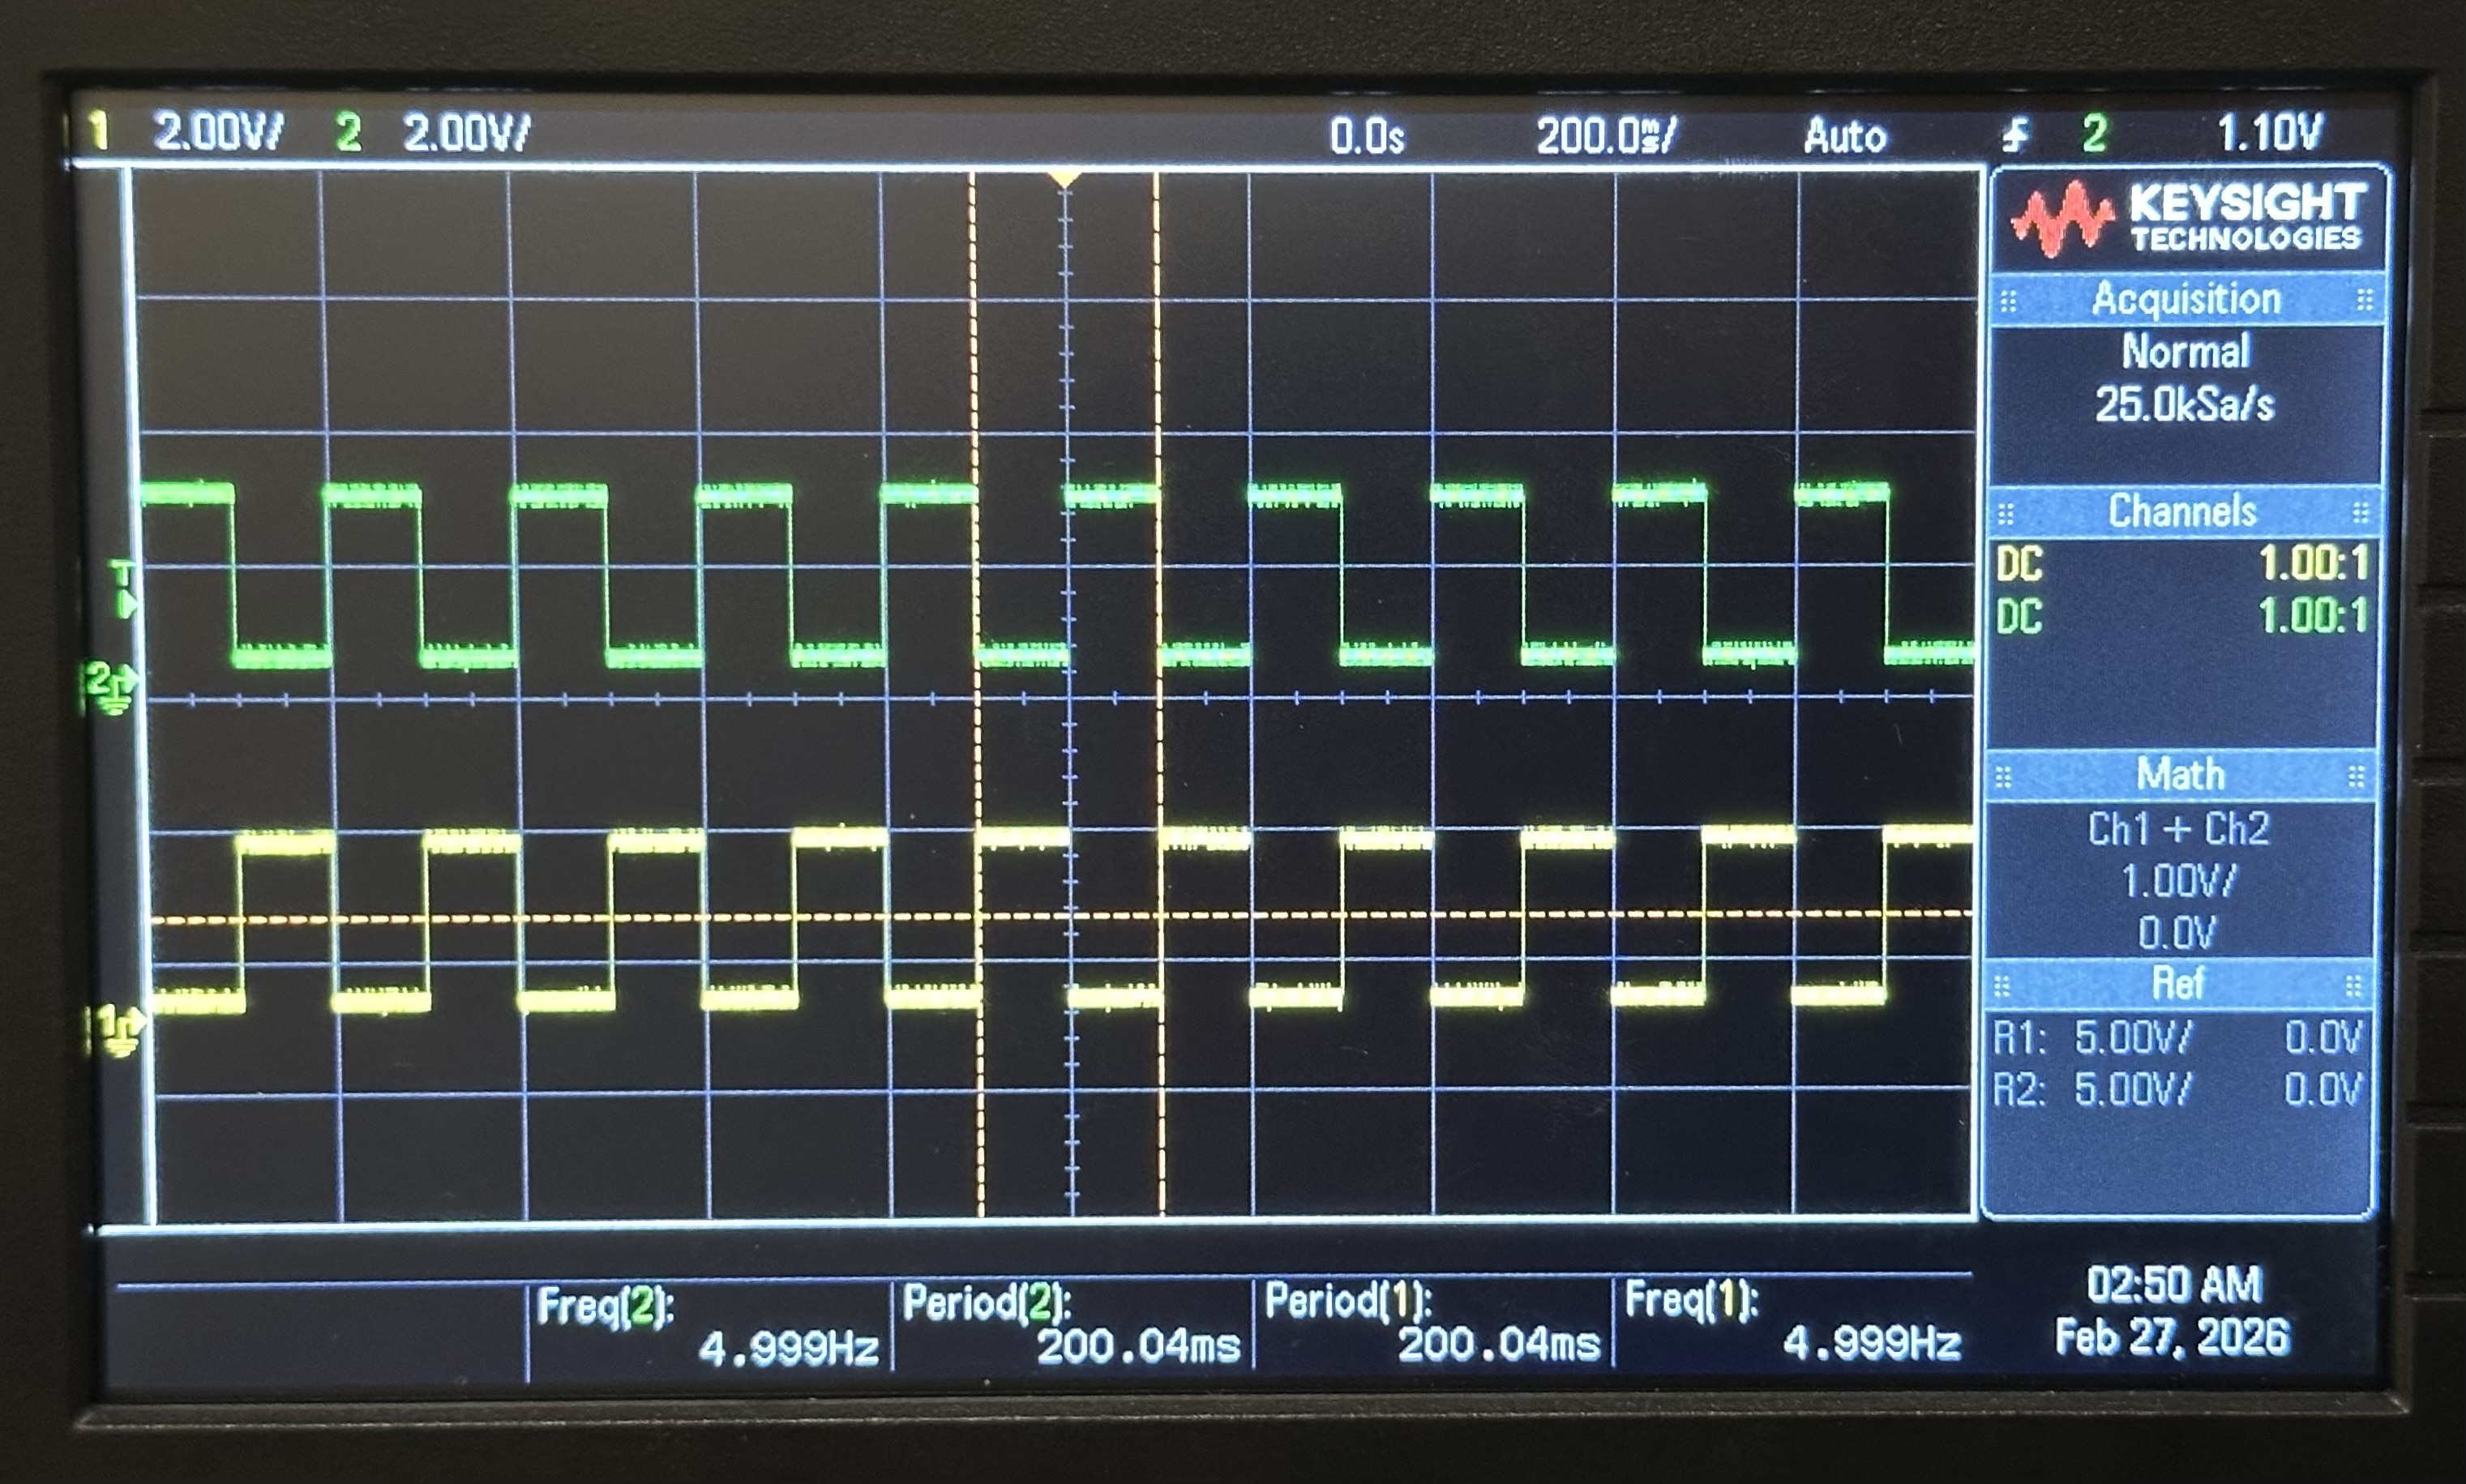

In [31]:
display(Image("scope_5Hz.jpeg"))

In [32]:
import pandas as pd

scope = pd.DataFrame({
    "Condition": ["Action min (1 Hz)", "Action max (5 Hz)"],
    "Measured Period (ms)": [1000.0, 200.04], 
    "Nominal Period (ms)":  [1000.0, 200.0],
    "Resolution (ms)":      [0.1, 0.04]
})

scope["Half Resolution (ms)"] = scope["Resolution (ms)"] / 2

scope["95% CI (ms)"] = scope.apply(
    lambda row: (
        round(row["Measured Period (ms)"] - row["Half Resolution (ms)"], 3),
        round(row["Measured Period (ms)"] + row["Half Resolution (ms)"], 3)
    ),
    axis=1
)

scope["Error vs Nominal (ms)"] = scope["Measured Period (ms)"] - scope["Nominal Period (ms)"]

scope

,Condition,Measured Period (ms),Nominal Period (ms),Resolution (ms),Half Resolution (ms),95% CI (ms),Error vs Nominal (ms)
0,Action min (1 Hz),1000.00,1000.0,0.10,0.05,"(999.95, 1000.05)",0.00
1,Action max (5 Hz),200.04,200.0,0.04,0.02,"(200.02, 200.06)",0.04


## Discussion

The measured frequencies from both logging analysis and oscilloscope measurements closely matched their nominal specifications. For the action LEDs, measured means were approximately 1 Hz, 2 Hz, and 5 Hz for the slowest, default, and fastest settings, respectively. The heartbeat LED remained at approximately 1 Hz across all action frequency configurations, as expected.

Repeated logging measurements produced identical period values within each condition, resulting in a sample standard deviation of zero. This does not imply perfect physical timing precision, but rather reflects the finite resolution of the timestamp source (k_uptime_ticks()), which is quantized to one system tick. Accordingly, the 95% confidence interval was estimated as +/- half a system tick in the period domain, consistent with the lab guidance.

Oscilloscope measurements independently confirmed the logging-based results. Measured periods and frequencies aligned nearly perfectly with the calculated values from the logging data. Overlaying both action LED signals demonstrated that they were exactly 180 degrees out of phase: when one LED was high, the other was low. This confirms correct phase toggling behavior in the action timer handler.

Overall, the timers behaved as designed, and no significant deviation from nominal values was observed. Any residual discrepancy (e.g., slight offset at 5 Hz) is attributable to quantization effects and conversion between tick counts and nanoseconds rather than instability in the timer implementation.